Имеется выборка некоторой СВ $\xi$ в виде интервального статистического ряда (табл.).  
Требуется:  
а) построить гистограмму и график эмпирической функции распределения $F_n(x)$;  
б) вычислить выборочные: среднее, дисперсию, медиану, нижний и верхний квартили, коэффициент вариации, коэффициент асимметрии, эксцесс, коэффициент эксцесса;  
в) добавить искусственно к данным большую флуктуацию (порядка 1000)  
Как изменятся вычисленные параметры? Почему?  

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
intervals = [(150,175), (175,200), (200,225), (225,250), (250,275)] # Интервалы
freq = np.array([160,340,345,135,20]) # Частоты
midpoints = np.array([(a+b)/2 for a,b in intervals]) # Середины интервалов
n = freq.sum() # Объем выборки

In [3]:
data = np.repeat(midpoints, freq) # Восстановление выборки (аппроксимация по средним)

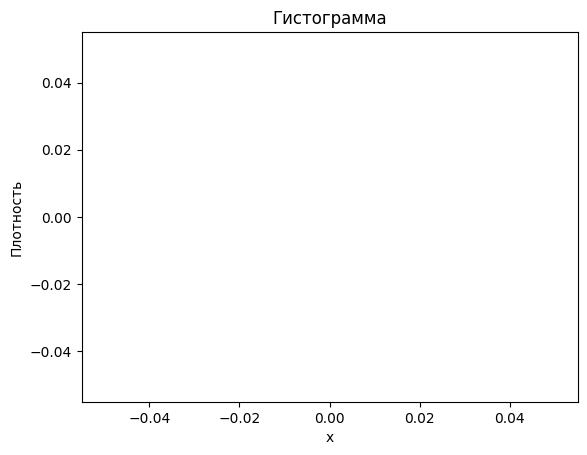

In [ ]:
# Гистограмма

plt.figure()
plt.hist(data, bins=[150,175,200,225,250,275], density=True)
plt.title("Гистограмма")
plt.xlabel("x")
plt.ylabel("Плотность")
plt.show()

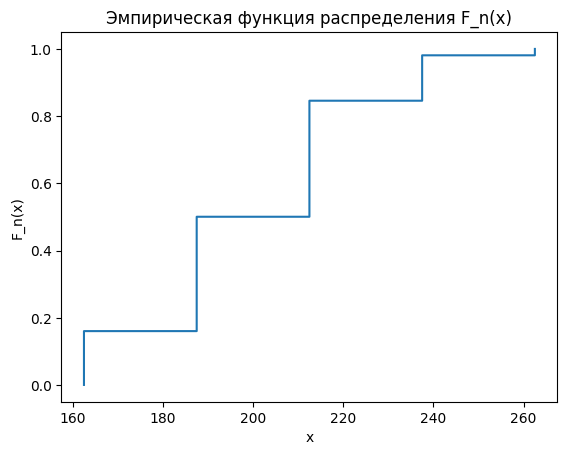

In [6]:
# Эмпирическая функция распределения

sorted_data = np.sort(data)
Fn = np.arange(1, n+1) / n

plt.figure()
plt.step(sorted_data, Fn)
plt.title("Эмпирическая функция распределения F_n(x)")
plt.xlabel("x")
plt.ylabel("F_n(x)")
plt.show()

## Характеристики

In [22]:
# Выборочные характеристики (NumPy)

mean = np.mean(data)
variance = np.var(data, ddof=1)
std = np.std(data, ddof=1)
median = np.median(data)
q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)
cv = std / mean
skewness = stats.skew(data, bias=False)
kurtosis = stats.kurtosis(data, bias=False)
excess_coef = kurtosis

print("Среднее:", mean)
print("Дисперсия:", variance)
print("Медиана:", median)
print("Q1:", q1)
print("Q3:", q3)
print("Коэффициент вариации:", cv)
print("Асимметрия:", skewness)
print("Эксцесс:", kurtosis + 3)
print("Коэффициент эксцесса:", excess_coef)

Среднее: 25.1
Дисперсия: 4.01005025125628
Медиана: 25.0
Q1: 24.0
Q3: 26.0
Коэффициент вариации: 0.07978131420520738
Асимметрия: 0.2404515133900239
Эксцесс: 2.504963884788682
Коэффициент эксцесса: -0.4950361152113181


In [23]:
# Выборочные характеристики (Python slices)

n = len(data)
mean = sum(data) / n
variance = sum((x - mean) ** 2 for x in data) / (n - 1)
std = variance ** 0.5
data_sorted = sorted(data)
if n % 2 == 0:
    median = (data_sorted[n//2 - 1] + data_sorted[n//2]) / 2
else:
    median = data_sorted[n//2]
q1 = data_sorted[n // 4]
q3 = data_sorted[3 * n // 4]
cv = std / mean
skewness = sum(((x - mean) / std) ** 3 for x in data) / n
kurtosis = sum(((x - mean) / std) ** 4 for x in data) / n
excess_coef = kurtosis - 3

print("Среднее:", mean)
print("Дисперсия:", variance)
print("Медиана:", median)
print("Q1:", q1)
print("Q3:", q3)
print("Коэффициент вариации:", cv)
print("Асимметрия:", skewness)
print("Эксцесс:", kurtosis)
print("Коэффициент эксцесса:", excess_coef)


Среднее: 25.1
Дисперсия: 4.0100502512562715
Медиана: 25.0
Q1: 24.0
Q3: 26.0
Коэффициент вариации: 0.0797813142052073
Асимметрия: 0.23685676326484334
Эксцесс: 2.462590875214367
Коэффициент эксцесса: -0.5374091247856332


## Выброс

In [20]:
# Выборочные характеристики с выбросом 1000 (NumPy)

data_outlier = np.append(data, 1000)

mean2 = np.mean(data_outlier)
variance2 = np.var(data_outlier, ddof=1)
std2 = np.std(data_outlier, ddof=1)
median2 = np.median(data_outlier)
q1_2 = np.percentile(data_outlier, 25)
q3_2 = np.percentile(data_outlier, 75)
cv2 = std2 / mean2
skewness2 = stats.skew(data_outlier, bias=False)
kurtosis2 = stats.kurtosis(data_outlier, bias=False)

print("Новое среднее:", mean2)
print("Новая дисперсия:", variance2)
print("Новая медиана:", median2)
print("Новое Q1:", q1_2)
print("Новое Q3:", q3_2)
print("Новый коэффициент вариации:", cv2)
print("Новая асимметрия:", skewness2)
print("Новый эксцесс:", kurtosis2 + 3)
print("Новый коэффициент эксцесса:", kurtosis2)


Новое среднее: 29.950248756218905
Новая дисперсия: 4732.497512437811
Новая медиана: 26.0
Новое Q1: 24.0
Новое Q3: 26.0
Новый коэффициент вариации: 2.296914150710191
Новая асимметрия: 14.159346788777853
Новый эксцесс: 203.65610680062724
Новый коэффициент эксцесса: 200.65610680062724


In [21]:
# Выборочные характеристики с выбросом 1000 (Python Slices)

data_outlier = list(data.copy())
data_outlier.append(1000)

n2 = len(data_outlier)
mean2 = sum(data_outlier) / n2
variance2 = sum((x - mean2) ** 2 for x in data_outlier) / (n2 - 1)
std2 = variance2 ** 0.5
data_sorted2 = sorted(data_outlier)
if n2 % 2 == 0:
    median2 = (data_sorted2[n2//2 - 1] + data_sorted2[n2//2]) / 2
else:
    median2 = data_sorted2[n2//2]
q1_2 = data_sorted2[n2 // 4]
q3_2 = data_sorted2[3 * n2 // 4]
cv2 = std2 / mean2
skewness2 = sum(((x - mean2) / std2) ** 3 for x in data_outlier) / n2
kurtosis2 = sum(((x - mean2) / std2) ** 4 for x in data_outlier) / n2

print("Новое среднее:", mean2)
print("Новая дисперсия:", variance2)
print("Новая медиана:", median2)
print("Новое Q1:", q1_2)
print("Новое Q3:", q3_2)
print("Новый коэффициент вариации:", cv2)
print("Новая асимметрия:", skewness2)
print("Новый эксцесс:", kurtosis2 + 3)
print("Новый коэффициент эксцесса:", kurtosis2)

Новое среднее: 29.950248756218905
Новая дисперсия: 4732.497512437811
Новая медиана: 26.0
Новое Q1: 24.0
Новое Q3: 26.0
Новый коэффициент вариации: 2.296914150710191
Новая асимметрия: 13.948714195028797
Новый эксцесс: 199.69770746676232
Новый коэффициент эксцесса: 196.69770746676232


## Наблюдения
**Среднее** - немного возросло  
**Дисперсия** - сильно возросла, поскольку она содержит квадраты отклонения, что является достаточно большой величиной  
**Коэффициент вариации** - резко возростает так как возрастает стандартное отклонение  
**Асимметрия** - появляется "тяжелый правый хвост"  
**Эксцесс** - резко возрастет т.к. оно становится "островершинным"  

## Вывод  
Дисперсия, асимметрия, эксцесс, среднее - *неустойчивые* оценки  
Медиана, квартили - *устойчивые* оценки